コイルのインダクタンスをワニ口によって変えた

In [2]:
# 自作モジュールへの変更を自動的にリロードするためのおまじない
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import lib.S2Z as stoz
import lib.Z_model as zmodel
import lib.Useful as usf

<Figure size 640x480 with 0 Axes>

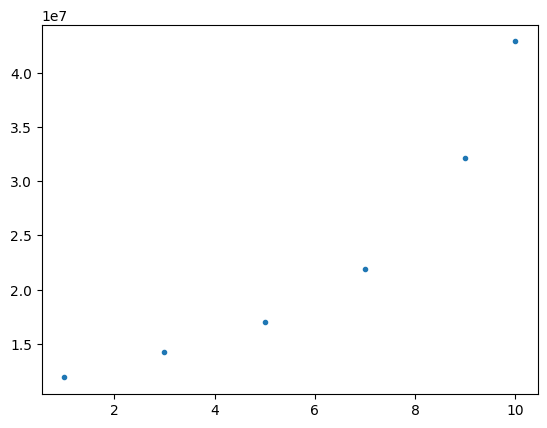

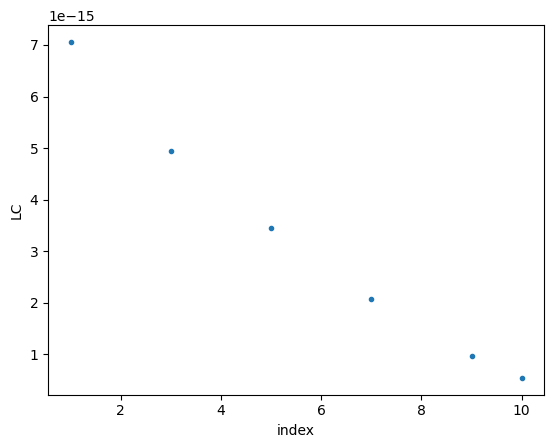

<Figure size 640x480 with 0 Axes>

In [16]:
indices = [1, 3, 5, 7, 9, 10]
S11 = []
for i in sorted(indices):
    data =  np.loadtxt(f"../data/coil_shorten/idx_{i}.s1p")
    s11 = data[:,1] + 1j*data[:,2]
    S11.append(s11)

data =  np.loadtxt(f"../data/coil_shorten/idx_0.s1p")
freq = data[:,0]

freq_at_abs_s11_min = []

for s11 in S11:
    freq_min = freq[np.argmin(np.abs(s11))]
    freq_at_abs_s11_min.append(freq_min)

plt.plot(indices, freq_at_abs_s11_min, ".")
plt.figure()

#(1/f)^2 = LCをみて、線形になっているか確認する
freq_at_min = np.array(freq_at_abs_s11_min)
LC = (1/freq_at_min)**2

plt.plot(indices, LC, ".")
plt.xlabel('index')
plt.ylabel('LC')
plt.figure()